In [25]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

pd.set_option('display.max_columns', 50)
CSV_PATH = Path('heart_disease_data.csv')

In [27]:
# Load dataset
if not CSV_PATH.exists():
    raise FileNotFoundError(f"CSV not found at {CSV_PATH.resolve()} — please update CSV_PATH to your local file.")

df = pd.read_csv(CSV_PATH)
print('Shape:', df.shape)
df.head()

Shape: (253680, 22)


,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [29]:
# Basic info
print('\nData types:')
print(df.dtypes)

print('\nNulls per column:')
print(df.isna().sum())

print('\nUnique value counts (first 10 columns):')
for c in df.columns[:10]:
    print(f"{c}: {df[c].nunique()}")



Data types:
HeartDiseaseorAttack    float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
Diabetes                float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64
dtype: object

Nulls per column:
HeartDiseaseorAttack    0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
Diabetes                0
PhysActivity            0
Fruits          

In [31]:
# Expected columns in Kaggle BRFSS 2015 heart indicators dataset
expected_cols = [
    'HeartDiseaseorAttack','HighBP','HighChol','CholCheck','BMI','Smoker','Stroke','Diabetes',
    'PhysActivity','Fruits','Veggies','HvyAlcoholConsump','AnyHealthcare','NoDocbcCost','GenHlth',
    'MentHlth','PhysHlth','DiffWalk','Sex','Age','Education','Income'
]

missing_cols = [c for c in expected_cols if c not in df.columns]
if missing_cols:
    print('WARNING: Missing expected columns:', missing_cols)

# Define variable types (binary, ordinal/categorical, and numeric-continuous)
binary_cols = [
    'HeartDiseaseorAttack','HighBP','HighChol','CholCheck','Smoker','Stroke','PhysActivity','Fruits',
    'Veggies','HvyAlcoholConsump','AnyHealthcare','NoDocbcCost','DiffWalk','Sex'
]
ordinal_cols = ['GenHlth','Age','Education','Income']  # coded integers
continuous_cols = ['BMI','MentHlth','PhysHlth']

# Sanity check presence
binary_cols = [c for c in binary_cols if c in df.columns]
ordinal_cols = [c for c in ordinal_cols if c in df.columns]
continuous_cols = [c for c in continuous_cols if c in df.columns]

print('\nDetected groups:')
print('Binary:', binary_cols)
print('Ordinal:', ordinal_cols)
print('Continuous:', continuous_cols)


Detected groups:
Binary: ['HeartDiseaseorAttack', 'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']
Ordinal: ['GenHlth', 'Age', 'Education', 'Income']
Continuous: ['BMI', 'MentHlth', 'PhysHlth']


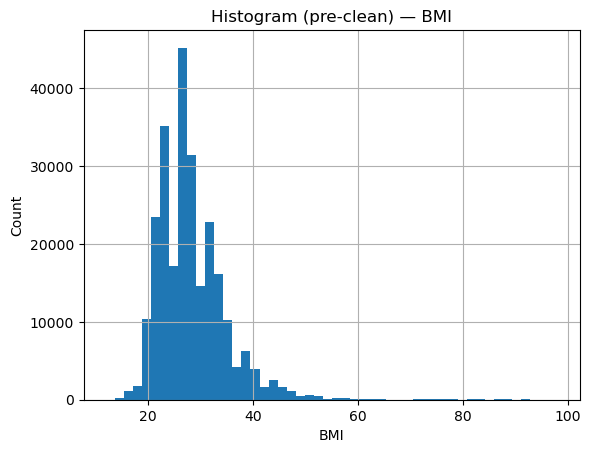

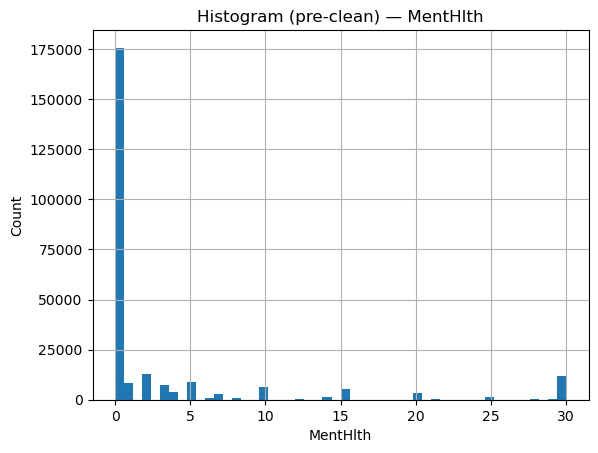

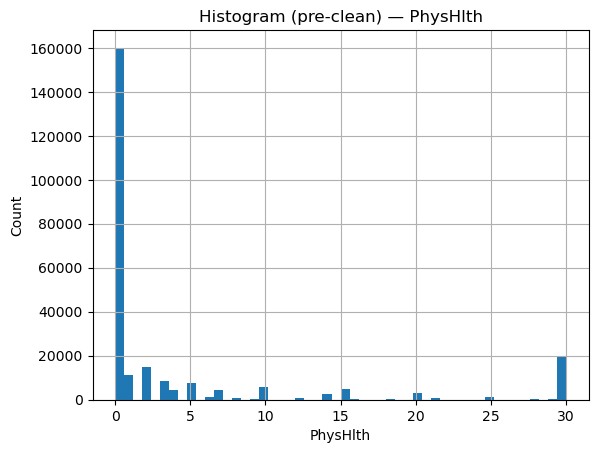

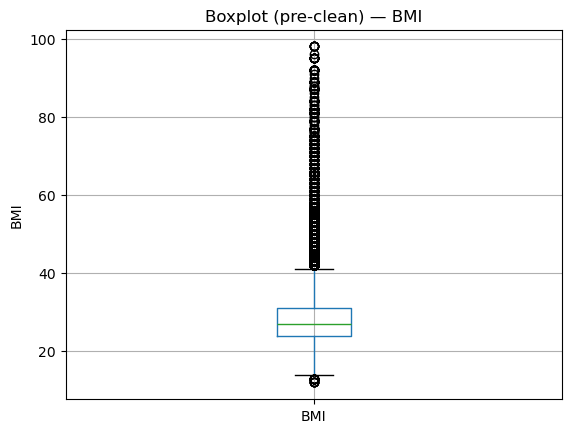

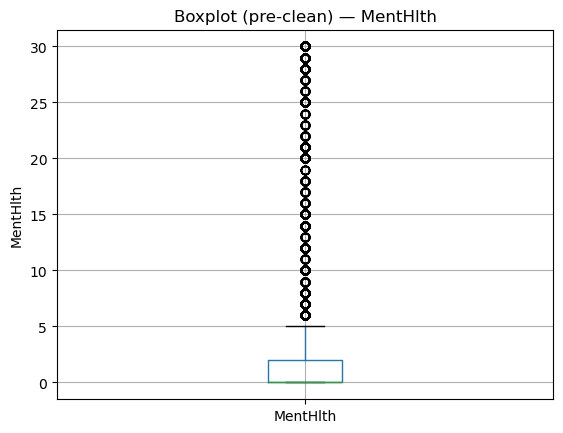

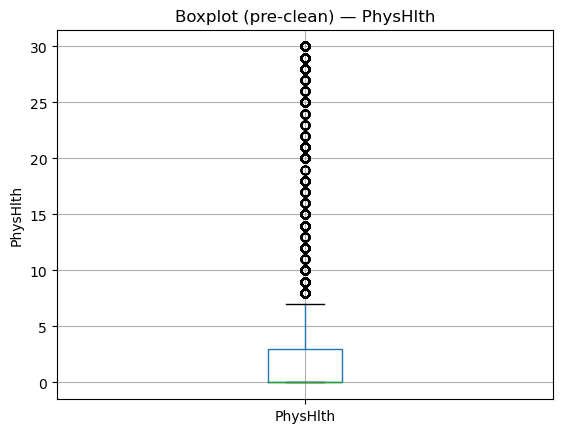

In [33]:

# Histograms (pre-cleaning)
for col in continuous_cols:
    df[col].hist(bins=50)
    plt.title(f'Histogram (pre-clean) — {col}')
    plt.xlabel(col); plt.ylabel('Count')
    plt.show()

# Boxplots (pre-cleaning)
for col in continuous_cols:
    df.boxplot(column=col)
    plt.title(f'Boxplot (pre-clean) — {col}')
    plt.ylabel(col)
    plt.show()

In [35]:
# --- Rules ---
# BMI: cap at 60 (winsorize extreme right tail)
BMI_MAX = 60

# MentHlth / PhysHlth should be in [0, 30]
MENT_PHYS_MIN, MENT_PHYS_MAX = 0, 30

# drop rows with implausible values instead of capping/clipping
DROP_IMPOSSIBLE = False

df_clean = df.copy()

# Track issues before cleaning
issues = {}

# BMI handling
if 'BMI' in df_clean.columns:
    issues['BMI_gt_max'] = int((df_clean['BMI'] > BMI_MAX).sum())
    if DROP_IMPOSSIBLE:
        df_clean = df_clean[df_clean['BMI'] <= BMI_MAX].copy()
    else:
        df_clean.loc[df_clean['BMI'] > BMI_MAX, 'BMI'] = BMI_MAX

# MentHlth & PhysHlth domain clipping
for col in ['MentHlth','PhysHlth']:
    if col in df_clean.columns:
        lower_viol = int((df_clean[col] < MENT_PHYS_MIN).sum())
        upper_viol = int((df_clean[col] > MENT_PHYS_MAX).sum())
        issues[f'{col}_lt_min'] = lower_viol
        issues[f'{col}_gt_max'] = upper_viol
        if DROP_IMPOSSIBLE:
            df_clean = df_clean[(df_clean[col] >= MENT_PHYS_MIN) & (df_clean[col] <= MENT_PHYS_MAX)].copy()
        else:
            df_clean[col] = df_clean[col].clip(MENT_PHYS_MIN, MENT_PHYS_MAX)

# Validate binary columns are in {0,1}; flag any anomalies
binary_anomalies = {}
for col in binary_cols:
    if col in df_clean.columns:
        valid = {0,1}
        bad_mask = ~df_clean[col].isin(valid)
        n_bad = int(bad_mask.sum())
        if n_bad > 0:
            binary_anomalies[col] = n_bad
            if DROP_IMPOSSIBLE:
                df_clean = df_clean[df_clean[col].isin(valid)].copy()
            else:
                # Coerce any non {0,1} close values via rounding then re-clip
                df_clean[col] = np.round(df_clean[col]).clip(0,1)

issues['binary_anomalies'] = binary_anomalies

# Validate ordinal ranges
# GenHlth (1-5), Age (1-13), Education (1-6), Income (1-8)
ordinal_ranges = {'GenHlth': (1,5), 'Age': (1,13), 'Education': (1,6), 'Income': (1,8)}
ordinal_out_of_range = {}

for col, (lo, hi) in ordinal_ranges.items():
    if col in df_clean.columns:
        mask_bad = (df_clean[col] < lo) | (df_clean[col] > hi)
        n_bad = int(mask_bad.sum())
        if n_bad > 0:
            ordinal_out_of_range[col] = n_bad
            if DROP_IMPOSSIBLE:
                df_clean = df_clean[~mask_bad].copy()
            else:
                # Clip to valid code ranges but also collect report
                df_clean[col] = df_clean[col].clip(lo, hi)

issues['ordinal_out_of_range'] = ordinal_out_of_range

print('=== Issues detected (pre-clean) ===')
for k,v in issues.items():
    print(k, '->', v)

print('\nShape before:', df.shape, '| after:', df_clean.shape)

=== Issues detected (pre-clean) ===
BMI_gt_max -> 805
MentHlth_lt_min -> 0
MentHlth_gt_max -> 0
PhysHlth_lt_min -> 0
PhysHlth_gt_max -> 0
binary_anomalies -> {}
ordinal_out_of_range -> {}

Shape before: (253680, 22) | after: (253680, 22)


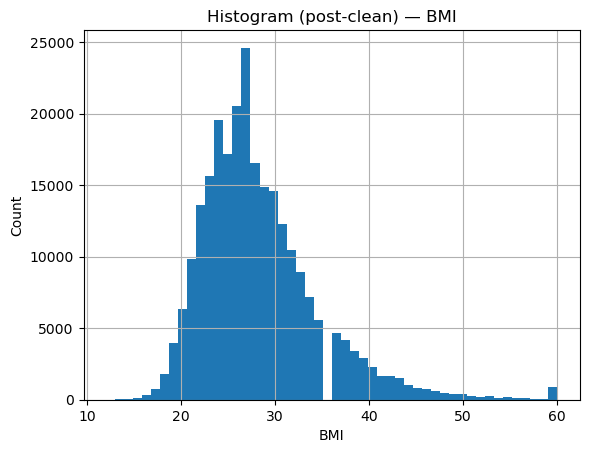

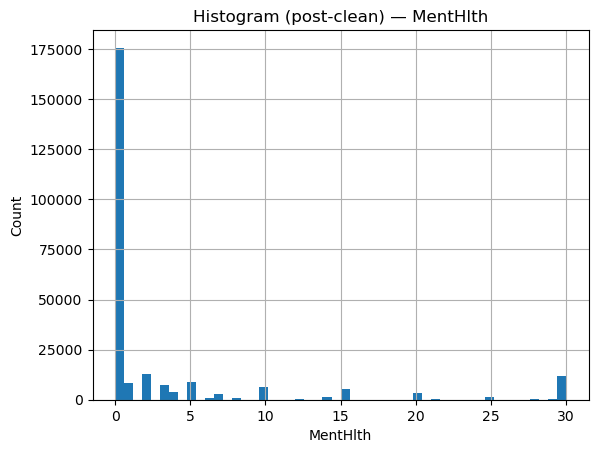

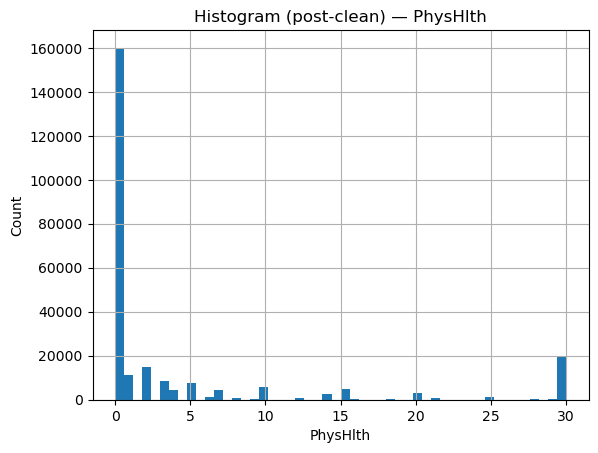

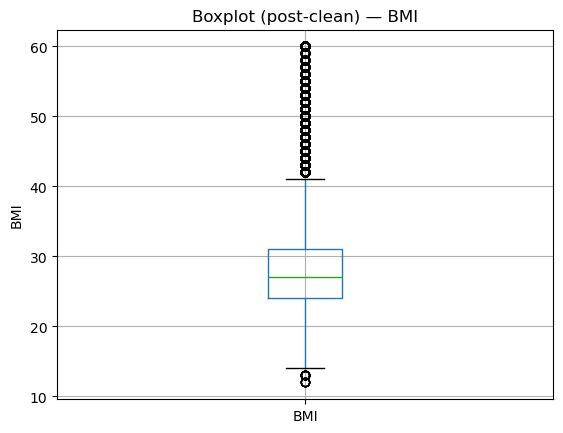

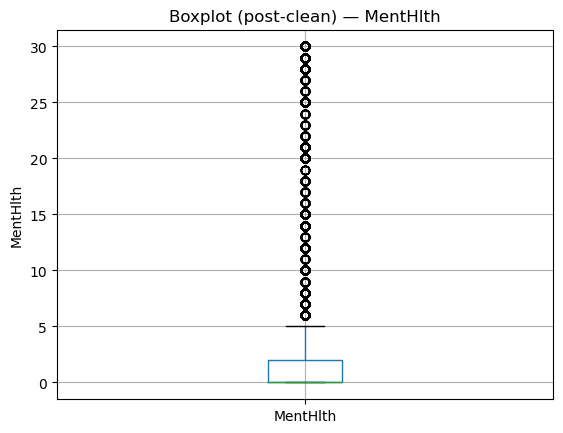

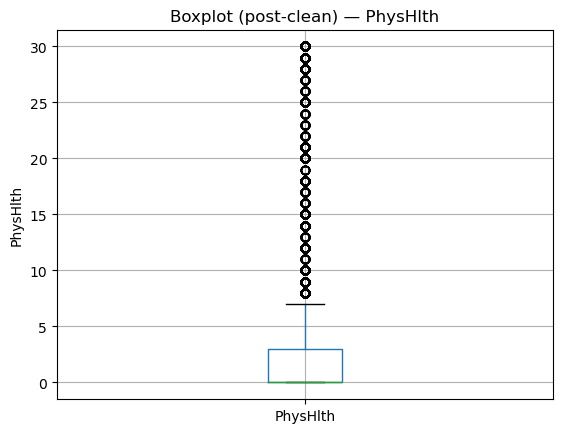

In [37]:
# Histograms (post-cleaning)
for col in ['BMI','MentHlth','PhysHlth']:
    if col in df_clean.columns:
        df_clean[col].hist(bins=50)
        plt.title(f'Histogram (post-clean) — {col}')
        plt.xlabel(col); plt.ylabel('Count')
        plt.show()

# Boxplots (post-cleaning)
for col in ['BMI','MentHlth','PhysHlth']:
    if col in df_clean.columns:
        df_clean.boxplot(column=col)
        plt.title(f'Boxplot (post-clean) — {col}')
        plt.ylabel(col)
        plt.show()

In [39]:
def iqr_outlier_counts(series: pd.Series, k: float = 1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k*iqr
    upper = q3 + k*iqr
    low_n = int((series < lower).sum())
    high_n = int((series > upper).sum())
    return {'q1': q1, 'q3': q3, 'iqr': iqr, 'lower': lower, 'upper': upper, 'below': low_n, 'above': high_n}

report = {}
for col in ['BMI','MentHlth','PhysHlth']:
    if col in df_clean.columns:
        report[col] = iqr_outlier_counts(df_clean[col].dropna())

print('IQR Outlier Report (post-clean):')
for col, stats in report.items():
    print(f"\n{col}:")
    for k,v in stats.items():
        print(f"  {k}: {v}")

IQR Outlier Report (post-clean):

BMI:
  q1: 24.0
  q3: 31.0
  iqr: 7.0
  lower: 13.5
  upper: 41.5
  below: 27
  above: 9820

MentHlth:
  q1: 0.0
  q3: 2.0
  iqr: 2.0
  lower: -3.0
  upper: 5.0
  below: 0
  above: 36208

PhysHlth:
  q1: 0.0
  q3: 3.0
  iqr: 3.0
  lower: -4.5
  upper: 7.5
  below: 0
  above: 40949


In [41]:
OUT_PATH = Path('cleaned_data.csv')
df_clean.to_csv(OUT_PATH, index=False)
print(f'Saved cleaned CSV to: {OUT_PATH.resolve()}')

Saved cleaned CSV to: C:\Users\Sarah\3031ICT Data Mining\Group Project\cleaned_data.csv


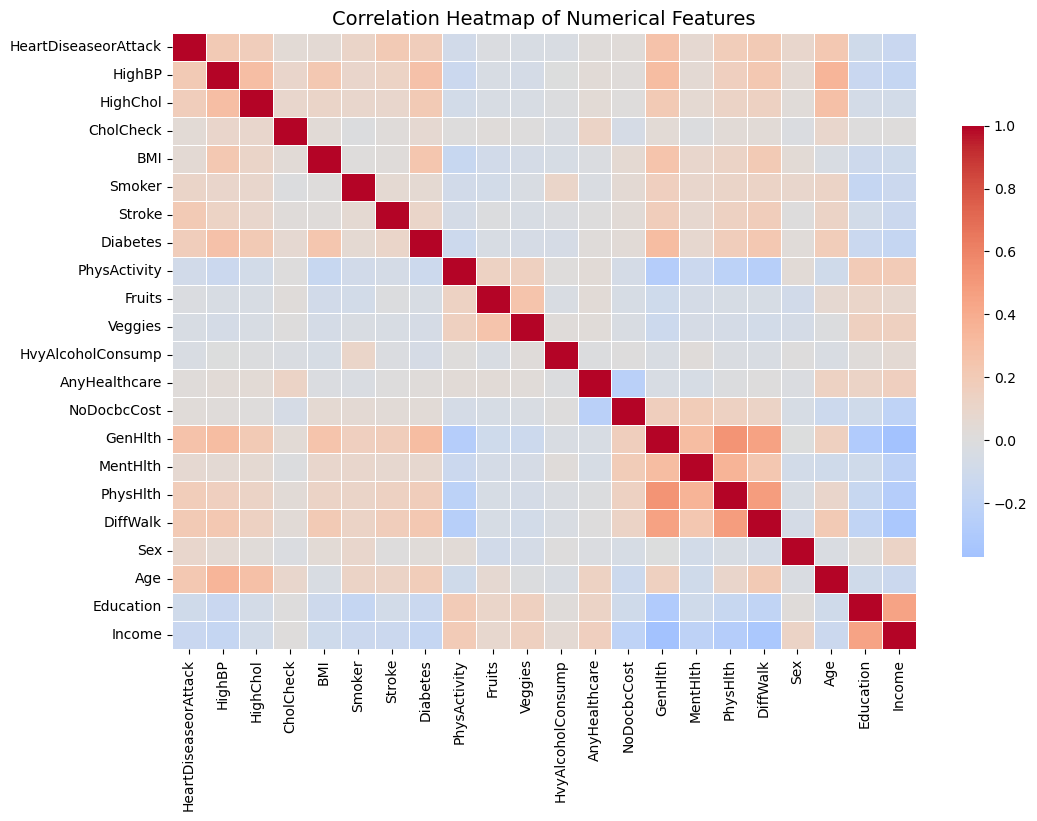

In [42]:
# Compute correlation matrix
num_df = df_clean.select_dtypes(include=[np.number])
corr = num_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, 
            fmt=".2f", linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title("Correlation Heatmap of Numerical Features", fontsize=14)
plt.show()